In [5]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta
import itertools, math
from typing import Iterable, Callable
import importlib
import fxshort_gates 
import config
import functions2 
import functions1
importlib.reload(fxshort_gates)
importlib.reload(functions2)

# ALL PARAMETERS
MAX_AGE = 24
print ('MAX_AGE:', MAX_AGE)
window_start = '2025-4-10'
window_end = '2025-10-11'

MAX_AGE: 24


In [6]:
ticker = 'GBPCHF.FOREX'

df = functions1.fetch_csv_robust(ticker=ticker,params=config.params)
s = functions1.sort_cols(df)
s= functions2.standardize_fx_daily_index(s)
s = functions2.trim_series(s, window_start, )
print(ticker)
print(s.index[0].date())
print(s.index[-1].date())

sort_cols: ohlc not set. True only needd for ATR calculations for vol stops. Defaulting to False
GBPCHF.FOREX
2025-04-10
2025-10-21


### Run gate with Frozen params

In [7]:

carry_ann = 0.04


print(ticker)
gate_stateon = fxshort_gates.fxshort_gate(
    # 2025-4-10
    s,
    carry_ann=carry_ann,
    buffer20=0.00,

    slope_window=15,
    consec=2,
    slope_entry_threshold=-1e-4,
    slope_exit_threshold=0.000,
    grace_days=2,

    require_carry=False,
    shift_for_signal=True,
    consec_rises_kill=3, 
    min_run_days=3,
    slope_source="log_price"
)

# --- Example usage after you compute gate_stateon ---
trades, stats = fxshort_gates.analyze_gate_trades(s, gate_stateon, position="short")
# print(trades.head(1))
print(stats)
# After you get trades from analyze_gate_trades
FEE_PER_TRADE = 0.00004  # 5bp round-trip, adjust as needed
trades["carry_cost"] = trades["holding_days"] * (carry_ann / 365)
trades["fee_cost"] = FEE_PER_TRADE
trades["net_pct_return"] = trades["pct_return"] - trades["carry_cost"] - trades["fee_cost"]

# Recompute summary stats on net_pct_return..... 0.00128
net_expectancy = trades["net_pct_return"].mean()
print(f"Net expectancy per trade after carry and fees: {net_expectancy:.5f}")
print('GATE ON NOW?', gate_stateon.iloc[-1])

GBPCHF.FOREX
{'trades': 5, 'win_rate': 0.6, 'total_pct_return': np.float64(0.033834944805920794), 'avg_pct_return': np.float64(0.006766988961184159), 'avg_win': np.float64(0.015595303228995749), 'avg_loss': np.float64(-0.006475482440533228), 'expectancy_per_trade': np.float64(0.006766988961184157), 'median_holding_days': 10.0, 'avg_MFE_pct': np.float64(0.0117478761504139), 'avg_MAE_pct': np.float64(0.0035536125424877373), 'max_draw_trade_pct': -0.011633317822242863, 'best_trade_pct': 0.03493175287356316}
Net expectancy per trade after carry and fees: 0.00445
GATE ON NOW? True


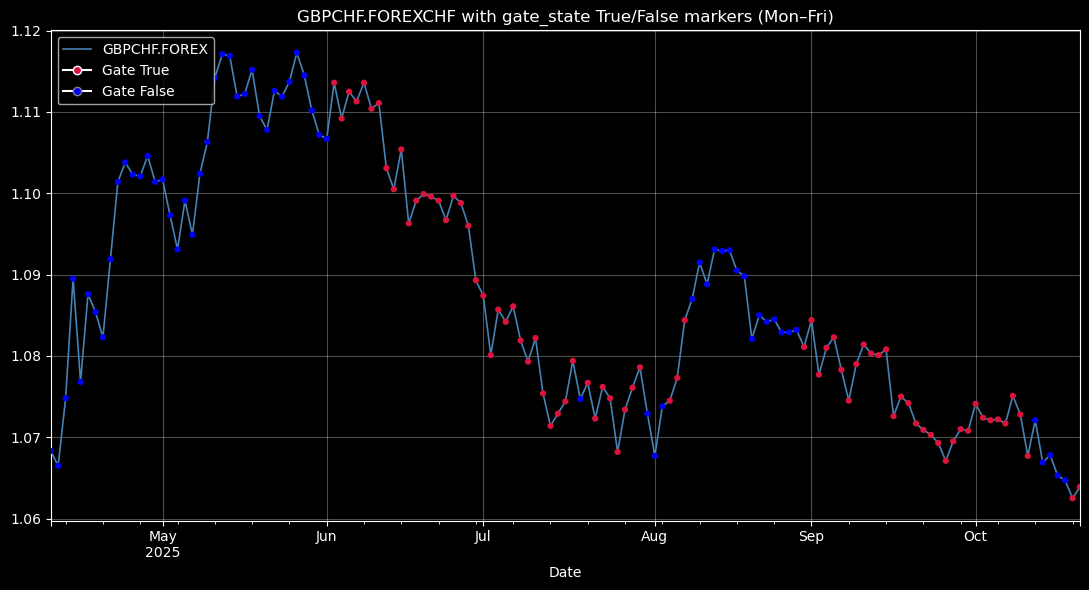

In [8]:

plt.style.use('dark_background')

TAIL_BARS = 1000
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = functions2.standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label=ticker)
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title(f'{ticker}CHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 ### Run sweep once a week/month

In [9]:
results, start, end = fxshort_gates.sweep_fxshort_gate(
    ticker,
    price=s,
    gate_fn=fxshort_gates.fxshort_gate,        
    slope_window_vals=(4,5,6,8,10,12,15,16,20),
    consec_vals=(1,2,3),
    slope_entry_thr_vals=(0.0, -1e-4, -3e-4),
    slope_exit_thr_offsets=(0.0, 1e-4, 2e-4),
    consec_rises_kill_vals=(0,1,2,3,4),
    require_carry_vals=(False, True),
    buffer20_vals=(0.002,),
    max_combos=None,
    min_trades=18,
    grace_days_vals=(2,3)
)

# print('gateseries:', results[0]   )
top = fxshort_gates.summarize_top(results, top=1)
print(ticker)
print('window_start:',window_start, 'window_end:',window_end)
print(top.to_string(index=False))
# print('start:',start.date(), '\nend:',end.date())

GBPCHF.FOREX
window_start: 2025-4-10 window_end: 2025-10-11
Empty DataFrame
Columns: []
Index: []


### save results

In [10]:
save_pth = pathlib.Path('sweep_results.csv')
# round all floats in results to 3 decimal places for easier reading
results = results.round(3)
# add start and end dates to results
'''results['start_date'] = start.date()
results['end_date'] = end.date()
#  move start and end to front
cols = results.columns.tolist()
cols = ['start_date', 'end_date'] + [col for col in cols if col not in ['start_date', 'end_date']]
results = results[cols]'''


# to_save = (results, start, end)
results.to_csv(save_pth, mode='a', index=False, header=not os.path.exists(save_pth))